# Lab 3: Decision Tree Classification — Training, Evaluation & Overfitting

**Name:** Haseeb Hassan

**Student ID:** 023-24-0274

**Section:** H

**GitHub Profile:** [Haseeb-Hassan66](https://github.com/Haseeb-Hassan66)

**Kaggle Profile:** [haseebsamo66737](https://www.kaggle.com/haseebsamo66737)

**Dataset:** Telco Customer Churn (cleaned in Lab 2 — `clean_churn.csv`)

**Dataset Source:** [Telco Customer Churn — Kaggle](https://github.com/Haseeb-Hassan66/ML-Practice/blob/main/Week%202/telco-churn.csv)

---

## Part 1 — Problem Definition & Dataset Verification

**Task 1 & 2**
1. Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining. 
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business? 

In [1]:
# Task 1 — load and verify the cleaned dataset from Lab 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values remaining:", df.isnull().sum().sum())
df.head()

Shape: (7043, 20)

Data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Missing values remaining: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,Yes,43,Yes,Yes,Fiber Optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.30,4209.95,No
1,Male,0,Yes,Yes,67,Yes,Yes,Fiber Optic,Yes,Yes,No,Yes,No,No,One year,No,Electronic check,89.55,6038.55,No
2,Female,1,No,No,1,Yes,No,Fiber Optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,71.15,71.15,Yes
3,Female,1,Yes,No,72,Yes,Yes,Dsl,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),89.85,6697.35,No
4,Female,0,No,No,69,Yes,No,Dsl,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


**Answer 2 (restating the problem):**
I'm predicting `Churn` — whether a given customer will cancel their telecom service (Yes/No) — based on their account and service information. This matters to the business because it's much cheaper to retain an existing customer than to acquire a new one, so if the company can flag high-risk customers in advance, it can target them with retention offers before they actually leave.

---

## Part 2 — Feature & Target Preparation

**Tasks**

3. Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any identifier column still present.

4. Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping). 

5. Confirm X contains only numeric columns and has no missing values before moving on.

In [2]:
# Task 3 — Define target (y) and features (X)

# Encode the target variable: No = 0, Yes = 1
y = df['Churn'].map({'No': 0, 'Yes': 1})

# Remove the target column from the features
X = df.drop(columns=['Churn'])

# Check for any identifier-like columns
id_like = [c for c in X.columns if 'id' in c.lower()]

print("Identifier-like columns still in X:", id_like)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

Identifier-like columns still in X: []

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target distribution (%):
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


**Justification for Task 3:**
`Churn` is encoded as 0/1 (`No` → 0, `Yes` → 1) because the target should be numeric for the classifier. The `Churn` column is removed from `X`, and the identifier check confirms that no identifier-like columns remain as model features.

In [3]:
# Task 4 — Convert categorical features into numeric form

# Find all categorical columns
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

print("Categorical columns to encode:")
print(cat_cols)

# Apply one-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("\nShape of X after encoding:", X.shape)

X.head()

Categorical columns to encode:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape of X after encoding: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,43,99.30,4209.95,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,False,False
1,0,67,89.55,6038.55,True,True,True,True,False,True,...,False,False,False,False,True,False,False,False,True,False
2,1,1,71.15,71.15,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,72,89.85,6697.35,False,True,False,True,False,True,...,False,True,False,True,False,True,True,False,False,False
4,0,69,82.45,5555.30,False,False,False,True,False,False,...,False,True,False,True,False,True,True,True,False,False


**Answer 4 (encoding choice justification):**
I used one-hot encoding with `pd.get_dummies()` because the categorical features do not have a natural numerical order. One-hot encoding converts each category into a separate binary feature without introducing an artificial ranking. `drop_first=True` removes one category from each categorical variable to avoid redundant dummy columns.

In [4]:
# Task 5 — Confirm X contains only numeric columns and no missing values

# Check for non-numeric columns
non_numeric = X.select_dtypes(exclude=['number', 'bool']).columns.tolist()

print("Non-numeric columns remaining:")
print(non_numeric if non_numeric else "None")

# Check for missing values
missing_values = X.isnull().sum().sum()

print("\nMissing values in X:", missing_values)

# Display final feature information
print("\nFinal X shape:", X.shape)

print("\nData type counts:")
print(X.dtypes.value_counts())

Non-numeric columns remaining:
None

Missing values in X: 0

Final X shape: (7043, 30)

Data type counts:
bool       26
int64       2
float64     2
Name: count, dtype: int64


**Observation:** After one-hot encoding, all categorical features have been converted into numeric/Boolean columns. `X` contains no missing values, so the feature matrix is ready to be used with the scikit-learn Decision Tree classifier.

---

## Part 3 — Train/Test Split

**Tasks**

6. Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you found about the target's class balance in Lab 2? 

7. Report the shape of X_train, X_test, y_train, and y_test. 

In [5]:
# Task 6 — train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Churn rate in y_train:", round(y_train.mean(), 4))
print("Churn rate in y_test:", round(y_test.mean(), 4))
print("Churn rate in full y:", round(y.mean(), 4))

Churn rate in y_train: 0.2654
Churn rate in y_test: 0.2654
Churn rate in full y: 0.2654


**Answer 6 (why `stratify=y` is sensible):**

In Lab 2, I found that `Churn` is imbalanced, with approximately 73% of customers not churning and 27% churning. Using `stratify=y` ensures that the training and test sets maintain the same class distribution as the full dataset. In this split, the churn rate is exactly 0.2654 in the training set, test set, and full dataset, confirming that the class distribution was preserved.

In [6]:
# Task 7 — report shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


**Observation:** The dataset was split into 5,634 training samples and 1,409 test samples using an 80/20 split. Both training and test sets contain the same 30 features, while the target arrays contain one Churn value for each corresponding sample. The identical churn rate of 0.2654 in the training, test, and full datasets confirms that stratification preserved the class distribution.

---

## Part 4 — Baseline Decision Tree

**Tasks**

8. Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed). Generate predictions on both the training and test sets.

9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you? 

In [7]:
# Task 8 — baseline Decision Tree
from sklearn.tree import DecisionTreeClassifier

baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

train_pred_base = baseline_model.predict(X_train)
test_pred_base = baseline_model.predict(X_test)

print("Baseline tree trained.")

Baseline tree trained.


In [8]:
# Task 9 — how deep did the tree grow on its own?
print("Depth scikit-learn grew the baseline tree to:", baseline_model.get_depth())
print("Number of leaves:", baseline_model.get_n_leaves())

Depth scikit-learn grew the baseline tree to: 24
Number of leaves: 1088


**Answer 9 (does the depth surprise me?):**

Scikit-learn grew the unrestricted baseline Decision Tree to a depth of 24, with 1,088 leaves. The depth is relatively large, which suggests that the tree has become quite complex and may be learning very specific patterns in the training data. However, I will compare training and test performance in the overfitting experiment to determine whether this complexity actually leads to overfitting.

---

## Part 5 — Model Evaluation

**Tasks**

10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table. 

11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss? 

12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [9]:
# Task 10 — accuracy, precision, recall, F1 on the test set
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

acc = accuracy_score(y_test, test_pred_base)
prec = precision_score(y_test, test_pred_base)
rec = recall_score(y_test, test_pred_base)
f1 = f1_score(y_test, test_pred_base)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [acc, prec, rec, f1]
})
metrics_table["Value"] = metrics_table["Value"].round(4)
metrics_table

,Metric,Value
0,Accuracy,0.7268
1,Precision,0.4848
2,Recall,0.4706
3,F1-score,0.4776


[[848 187]
 [198 176]]


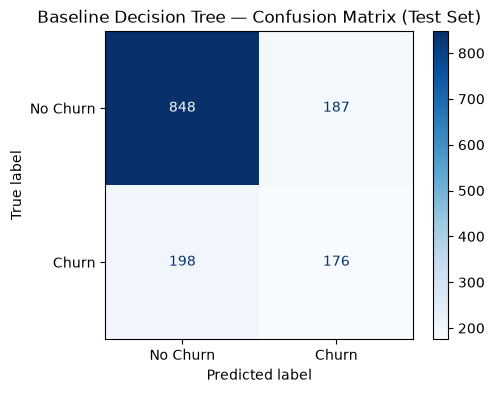

In [10]:
# Task 11 — confusion matrix for the test set
cm = confusion_matrix(y_test, test_pred_base)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Baseline Decision Tree — Confusion Matrix (Test Set)")
plt.show()

**Observation (Task 11):** Out of the 374 customers in the test set who actually churned, the baseline model correctly caught 176 of them (true positives) and missed 198 of them (false negatives — predicted "No" when they actually churned). It also raised 187 false alarms (predicted "Churn" for customers who actually stayed). So the baseline tree is missing slightly more than half of the actual churners, which is a real problem if the business goal is to proactively catch at-risk customers.

**Answer 12 (which metric(s) do I trust most, and why):**
Given the class imbalance found in Lab 2 (~73% No / ~27% Yes), I don't trust accuracy on its own — a model could get ~73% accuracy just by predicting "No" for everyone and never actually identifying a single churner. For this business problem I care most about **recall on the churn class**, because the cost of missing an actual churner (false negative — losing a customer we never tried to retain) is generally higher than the cost of a false alarm (offering a retention deal to someone who wasn't going to leave anyway). That said, recall alone can be gamed by predicting "Churn" for almost everyone, so I look at **F1-score** alongside it as a balance between precision and recall, rather than optimizing recall in isolation.

---

## Part 6 — Overfitting Investigation

**Tasks**

13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?

14. Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table. 

15. Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this. 

In [11]:
# Task 13 — baseline train vs. test accuracy
train_acc_base = accuracy_score(y_train, train_pred_base)
test_acc_base = accuracy_score(y_test, test_pred_base)

print("Baseline training accuracy:", round(train_acc_base, 4))
print("Baseline test accuracy:", round(test_acc_base, 4))
print("Gap (train - test):", round(train_acc_base - test_acc_base, 4))

Baseline training accuracy: 0.9977
Baseline test accuracy: 0.7268
Gap (train - test): 0.2709


**Answer 13 (is there a large gap?):**

Yes — there is a very large gap. The baseline tree achieves about 99.8% accuracy on the training data but only about 72.7% on the test data, giving a gap of approximately 27.1 percentage points. This large difference, together with the tree's depth of 24, strongly suggests that the unrestricted tree is overfitting and is not generalizing well to unseen customers.

In [12]:
# Task 14 — train/test accuracy across several max_depth values
depths_to_try = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for d in depths_to_try:
    model_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    model_d.fit(X_train, y_train)

    tr_acc = accuracy_score(y_train, model_d.predict(X_train))
    te_acc = accuracy_score(y_test, model_d.predict(X_test))

    results.append({
        "max_depth": "None (unrestricted)" if d is None else d,
        "Train Accuracy": round(tr_acc, 4),
        "Test Accuracy": round(te_acc, 4),
        "Gap": round(tr_acc - te_acc, 4)
    })

depth_results = pd.DataFrame(results)
depth_results

,max_depth,Train Accuracy,Test Accuracy,Gap
0,2,0.7881,0.7700,0.0180
1,3,0.7881,0.7700,0.0180
2,4,0.7929,0.7835,0.0093
3,5,0.8078,0.7743,0.0335
4,6,0.8152,0.7693,0.0459
5,8,0.8449,0.7715,0.0734
6,10,0.8821,0.7445,0.1376
7,None (unrestricted),0.9977,0.7268,0.2709


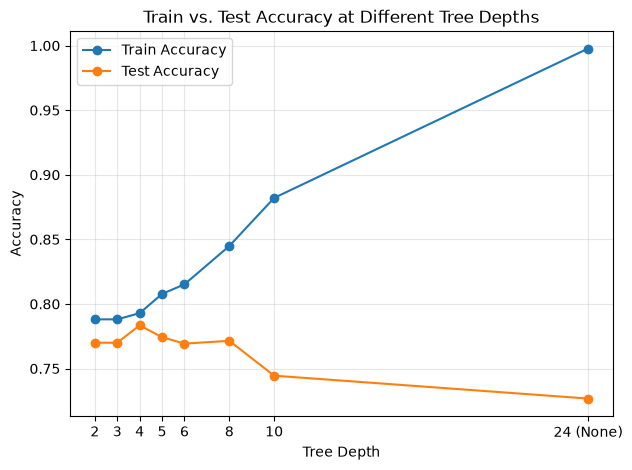

In [13]:
# Task 15 — plot train vs. test accuracy against max_depth

plot_depths = [2, 3, 4, 5, 6, 8, 10, 24]

train_accs = depth_results["Train Accuracy"].tolist()
test_accs = depth_results["Test Accuracy"].tolist()

plt.figure(figsize=(7, 5))

plt.plot(plot_depths, train_accs, marker='o', label='Train Accuracy')
plt.plot(plot_depths, test_accs, marker='o', label='Test Accuracy')

plt.xticks(plot_depths, ['2', '3', '4', '5', '6', '8', '10', '24 (None)'])

plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy at Different Tree Depths')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Answer 15 (where does overfitting start, and how does the chart show it?):**

Up to max_depth=4, training and test accuracy remain relatively close, and test accuracy reaches its highest value of 78.35%. Starting around max_depth=5, training accuracy continues to increase while test accuracy begins to decline, causing the train-test gap to widen. This indicates that the tree starts to overfit at approximately depth 5, with overfitting becoming increasingly severe at deeper values and reaching its largest gap for the unrestricted tree.

---

## Part 7 — Model Selection, Feature Importance & Interpretation

**Tasks**

16.  Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy. 

17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison against the baseline. 

18. Retrain a Decision Tree with “entropy” as the splitting criterion rather than the default (“gini”) and report its full evaluation metrics (as in Part 5) for comparison against the baseline. 

19. Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most? 

20. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then? 

**Answer 16 (chosen depth and justification):**

I’m choosing **`max_depth=4`**. Looking at the Part 6 results, depth 4 gives the **highest test accuracy** of all the depths tested (78.35%) while maintaining a very small train–test gap of about **0.9 percentage points** (79.29% training vs. 78.35% test accuracy). I’m not choosing deeper trees such as depth 10 or the unrestricted tree because, although their training accuracy is much higher, their test accuracy decreases, indicating increasing overfitting. Therefore, depth 4 provides the best balance between learning the training data and generalizing to unseen data.

In [14]:
# Task 17 — retrain at the chosen depth (max_depth=4) and evaluate fully
chosen_model = DecisionTreeClassifier(max_depth=4, random_state=42)
chosen_model.fit(X_train, y_train)

chosen_train_pred = chosen_model.predict(X_train)
chosen_test_pred = chosen_model.predict(X_test)

chosen_metrics = pd.DataFrame({
    "Metric": ["Train Accuracy", "Test Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline (unrestricted)": [
        round(train_acc_base, 4), round(test_acc_base, 4),
        round(prec, 4), round(rec, 4), round(f1, 4)
    ],
    "Chosen model (depth=4, gini)": [
        round(accuracy_score(y_train, chosen_train_pred), 4),
        round(accuracy_score(y_test, chosen_test_pred), 4),
        round(precision_score(y_test, chosen_test_pred), 4),
        round(recall_score(y_test, chosen_test_pred), 4),
        round(f1_score(y_test, chosen_test_pred), 4)
    ]
})
chosen_metrics

,Metric,Baseline (unrestricted),"Chosen model (depth=4, gini)"
0,Train Accuracy,0.9977,0.7929
1,Test Accuracy,0.7268,0.7835
2,Precision,0.4848,0.5856
3,Recall,0.4706,0.6310
4,F1-score,0.4776,0.6075


[[868 167]
 [138 236]]


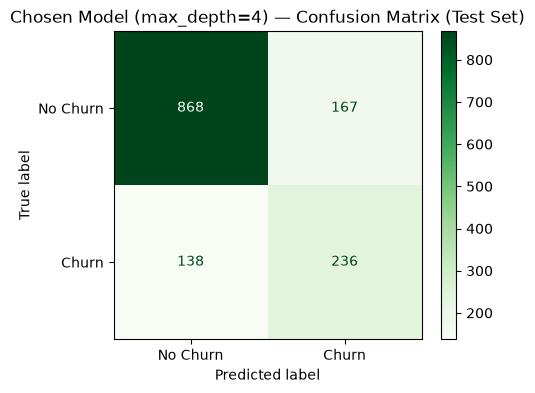

In [15]:
cm_chosen = confusion_matrix(y_test, chosen_test_pred)
print(cm_chosen)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_chosen, display_labels=["No Churn", "Churn"])
fig, ax = plt.subplots(figsize=(5, 4))
disp2.plot(ax=ax, cmap="Greens", values_format='d')
plt.title("Chosen Model (max_depth=4) — Confusion Matrix (Test Set)")
plt.show()

**Observation (Task 17):**

Compared to the unrestricted baseline, the depth-4 model has lower training accuracy (79.29% vs. 99.77%) but noticeably higher test accuracy (78.35% vs. 72.68%). It also performs better on the churn class, with recall improving from 47.06% to 63.10%, while precision increases from 48.48% to 58.56% and F1-score from 47.76% to 60.75%. This shows that the depth-4 model generalizes better to unseen customers and is more effective at identifying customers who actually churn.

In [16]:
# Task 18 — retrain with entropy criterion at the same depth, for comparison
entropy_model = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
entropy_model.fit(X_train, y_train)

entropy_test_pred = entropy_model.predict(X_test)

criterion_compare = pd.DataFrame({
    "Metric": ["Train Accuracy", "Test Accuracy", "Precision", "Recall", "F1-score"],
    "Gini (chosen)": [
        round(accuracy_score(y_train, chosen_train_pred), 4),
        round(accuracy_score(y_test, chosen_test_pred), 4),
        round(precision_score(y_test, chosen_test_pred), 4),
        round(recall_score(y_test, chosen_test_pred), 4),
        round(f1_score(y_test, chosen_test_pred), 4)
    ],
    "Entropy": [
        round(accuracy_score(y_train, entropy_model.predict(X_train)), 4),
        round(accuracy_score(y_test, entropy_test_pred), 4),
        round(precision_score(y_test, entropy_test_pred), 4),
        round(recall_score(y_test, entropy_test_pred), 4),
        round(f1_score(y_test, entropy_test_pred), 4)
    ]
})
criterion_compare

,Metric,Gini (chosen),Entropy
0,Train Accuracy,0.7929,0.7920
1,Test Accuracy,0.7835,0.7850
2,Precision,0.5856,0.6550
3,Recall,0.6310,0.4011
4,F1-score,0.6075,0.4975


**Observation (Task 18 — gini vs. entropy):**

At the same depth, the entropy-based tree achieves slightly higher test accuracy than the Gini tree (78.50% vs. 78.35%), but its recall for the churn class is much lower (40.11% vs. 63.10%). Although entropy has higher precision (65.50% vs. 58.56%), its lower recall and F1-score (49.75% vs. 60.75%) make the Gini model more suitable for this problem. Since identifying actual churners is important, I would keep the **Gini criterion** as the final choice rather than switching to entropy.

### Feature Importance

**Task 19** — Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most? 

tenure                              0.491171
InternetService_Fiber Optic         0.354303
Contract_Two year                   0.037832
OnlineBackup_No internet service    0.030605
TotalCharges                        0.027346
PaymentMethod_Electronic check      0.024412
MultipleLines_Yes                   0.015170
PhoneService_Yes                    0.012440
TechSupport_Yes                     0.006463
SeniorCitizen                       0.000257
dtype: float64


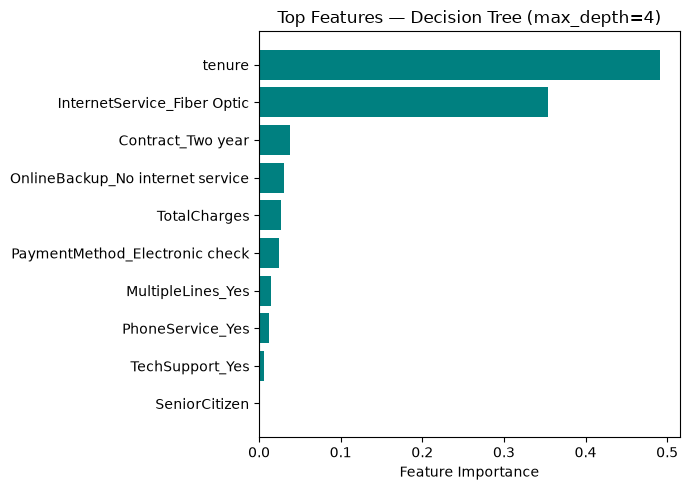

In [17]:
# Task 19 — feature importances for the chosen model
importances = pd.Series(chosen_model.feature_importances_, index=X.columns)
importances = importances[importances > 0].sort_values(ascending=False)

top_features = importances.head(10)
print(top_features)

plt.figure(figsize=(7, 5))
plt.barh(top_features.index[::-1], top_features.values[::-1], color='teal')
plt.xlabel('Feature Importance')
plt.title('Top Features — Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

**Observation (Task 19):**

The feature-importance results show that **tenure** is the most important feature according to the chosen decision tree, with an importance of approximately 0.49, followed by **InternetService_Fiber Optic** at approximately 0.35. Other contributing features include **Contract_Two year**, **OnlineBackup_No internet service**, and **TotalCharges**, although their importance is considerably smaller. This indicates that the tree relies primarily on tenure and fiber-optic internet service when making its churn predictions.

### Interpretation

**Task 20** — n 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then? 

**Answer 20 (connecting feature importance back to Lab 2 EDA):**

Yes, the feature-importance results agree with the patterns observed in my Lab 2 EDA. **Tenure** was associated with churn, with churned customers showing lower tenure, while **InternetService**, particularly Fiber optic service, showed a noticeably different churn pattern. **Contract** was also identified as an important categorical feature in the EDA, which is consistent with `Contract_Two year` appearing among the important features in the decision tree. Overall, the model's important features are consistent with the main patterns I observed during the EDA.

---

## Part 8 — Conclusion & Next Steps

**Task 21** — Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?

**Answer 21 (conclusion):**

I landed on a **Decision Tree with `max_depth=4` and the default Gini criterion** as my final model. It performs better than the unrestricted baseline, achieving **78.35% test accuracy, 58.56% precision, 63.10% recall, and 60.75% F1-score**, compared with 72.68% test accuracy and 47.06% recall for the baseline. The depth-4 model also has a much smaller train–test gap, indicating substantially less overfitting and better generalization to unseen customers. Its main limitations are that it still misses some actual churners and produces some false churn predictions, while its feature importance is heavily concentrated on `tenure` and `InternetService_Fiber Optic`. Therefore, it is a useful and interpretable model for this lab, but further validation and improvement would be needed before considering it for real-world use.

**Task 22** — What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here. 

If I had more time, I would first investigate **class imbalance** by trying techniques such as `class_weight='balanced'` or resampling methods such as SMOTE, with particular attention to improving recall for the churn class. I would also explore other algorithms for tabular data, such as **Random Forest or Gradient Boosting**, and compare their performance with the decision tree. Another useful step would be additional feature engineering, such as creating features that represent the number of subscribed services or grouping `tenure` into meaningful customer-duration categories. Finally, I would use **cross-validation** to evaluate the model across multiple splits and determine whether the observed performance is stable rather than depending on a single train/test split.

**Task 23** — Implement ID3 from scratch on the Play Badminton dataset from class. No built-in decision tree libraries — write your own entropy and information gain functions. Print the gain values for each attribute at every split.   

In [18]:
# Task 23 — ID3 from scratch on the Play Badminton dataset (no sklearn here)
import math
from collections import Counter

# Classic "Play Badminton" dataset from the AI course
play_badminton = pd.DataFrame({
    "Outlook":     ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                     "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temperature": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
                     "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity":    ["High","High","High","High","Normal","Normal","Normal",
                     "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind":        ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
                     "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "PlayBadminton": ["No","No","Yes","Yes","Yes","No","Yes",
                       "No","Yes","Yes","Yes","Yes","Yes","No"]
})

play_badminton

,Outlook,Temperature,Humidity,Wind,PlayBadminton
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [19]:
def entropy(labels):
    """Entropy of a list/Series of class labels."""
    counts = Counter(labels)
    total = len(labels)
    ent = 0.0
    for label, count in counts.items():
        p = count / total
        ent -= p * math.log2(p)
    return ent


def information_gain(data, attribute, target):
    """Information gain of splitting `data` on `attribute`, w.r.t. `target`."""
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0.0
    for value in data[attribute].unique():
        subset = data[data[attribute] == value]
        weighted_entropy += (len(subset) / total) * entropy(subset[target])

    return total_entropy - weighted_entropy


def id3(data, attributes, target, depth=0):
    """Recursively build a decision tree using the ID3 algorithm."""
    indent = "  " * depth

    # Base case 1: all examples have the same label
    if len(data[target].unique()) == 1:
        label = data[target].iloc[0]
        print(f"{indent}-> Leaf: all remaining examples are '{label}'")
        return label

    # Base case 2: no attributes left to split on
    if not attributes:
        majority = Counter(data[target]).most_common(1)[0][0]
        print(f"{indent}-> Leaf (no attributes left): majority class = '{majority}'")
        return majority

    # Compute information gain for every remaining attribute
    print(f"{indent}Node with {len(data)} examples — computing information gain:")
    gains = {}
    for attr in attributes:
        gain = information_gain(data, attr, target)
        gains[attr] = gain
        print(f"{indent}  Gain({attr}) = {gain:.4f}")

    best_attr = max(gains, key=gains.get)
    print(f"{indent}=> Splitting on '{best_attr}' (highest gain = {gains[best_attr]:.4f})\n")

    tree = {best_attr: {}}
    remaining_attributes = [a for a in attributes if a != best_attr]

    for value in data[best_attr].unique():
        subset = data[data[best_attr] == value]
        print(f"{indent}[{best_attr} = {value}]  ({len(subset)} examples)")
        if len(subset) == 0:
            majority = Counter(data[target]).most_common(1)[0][0]
            print(f"{indent}  -> Leaf (empty subset): majority class = '{majority}'")
            tree[best_attr][value] = majority
        else:
            tree[best_attr][value] = id3(subset, remaining_attributes, target, depth + 1)

    return tree


attributes = ["Outlook", "Temperature", "Humidity", "Wind"]
target = "PlayBadminton"

print("Root entropy of PlayBadminton:", round(entropy(play_badminton[target]), 4))
print()

id3_tree = id3(play_badminton, attributes, target)
print("\nFinal tree structure:")
id3_tree

Root entropy of PlayBadminton: 0.9403

Node with 14 examples — computing information gain:
  Gain(Outlook) = 0.2467
  Gain(Temperature) = 0.0292
  Gain(Humidity) = 0.1518
  Gain(Wind) = 0.0481
=> Splitting on 'Outlook' (highest gain = 0.2467)

[Outlook = Sunny]  (5 examples)
  Node with 5 examples — computing information gain:
    Gain(Temperature) = 0.5710
    Gain(Humidity) = 0.9710
    Gain(Wind) = 0.0200
  => Splitting on 'Humidity' (highest gain = 0.9710)

  [Humidity = High]  (3 examples)
    -> Leaf: all remaining examples are 'No'
  [Humidity = Normal]  (2 examples)
    -> Leaf: all remaining examples are 'Yes'
[Outlook = Overcast]  (4 examples)
  -> Leaf: all remaining examples are 'Yes'
[Outlook = Rain]  (5 examples)
  Node with 5 examples — computing information gain:
    Gain(Temperature) = 0.0200
    Gain(Humidity) = 0.0200
    Gain(Wind) = 0.9710
  => Splitting on 'Wind' (highest gain = 0.9710)

  [Wind = Weak]  (3 examples)
    -> Leaf: all remaining examples are 'Yes'
 

{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}},
  'Overcast': 'Yes',
  'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}

**Observation (Task 23):**

`Outlook` is selected as the first split because it has the highest information gain at the root (0.2467). The `Overcast` branch becomes a pure leaf immediately because all examples in that branch have the target value `Yes`. For the `Sunny` branch, `Humidity` has the highest remaining gain (0.9710), while for the `Rain` branch, `Wind` has the highest gain (0.9710), allowing both branches to be split into pure leaves. The implementation demonstrates how ID3 calculates entropy and information gain at each node and greedily selects the attribute with the highest information gain for the next split.

---

## Submission Checklist

- [x] Student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Source)
- [x] 1. Problem Definition
- [x] 2. Dataset Verification
- [x] 3. Feature/Target Preparation
- [x] 4. Train/Test Split
- [x] 5. Baseline Decision Tree
- [x] 6. Model Evaluation (accuracy, precision, recall, F1, confusion matrix)
- [x] 7. Overfitting Experiment (train vs. test comparison + multi-depth table & plot)
- [x] 8. Model Comparison (chosen depth vs. baseline, gini vs. entropy)
- [x] 9. Feature Importance (extracted and visualized)
- [x] 10. Interpretation (connected back to Lab 2 EDA)
- [x] 11. Conclusion (+ next steps, + ID3-from-scratch bonus task)
- [x] Every table/plot/metric has a written interpretation
- [x] No Random Forest / GridSearchCV / RandomizedSearchCV used
- [x] Notebook + `clean_churn.csv` ready to commit and push to GitHub